## Support Vector Regressor Implementation

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Lets create synthetic data points
from sklearn.datasets import make_regression

In [4]:
X,y=make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3.0)

In [5]:
X

array([[ 0.13459619,  0.32311061],
       [-0.19670493, -0.38078529],
       [-0.33973294,  1.87125864],
       ...,
       [-0.52258292,  0.69375619],
       [-0.56731561,  1.71750131],
       [ 1.20885219, -0.33738293]], shape=(1000, 2))

In [6]:
y

array([ 1.83388343e+01, -1.79727005e+01, -1.04801994e+01, -9.58676086e+01,
       -9.74907202e+01,  5.54206604e+01, -2.40065531e+01, -9.61441174e+00,
       -4.50675311e+01,  1.96263944e+02, -5.11079570e+01,  2.51239575e+01,
       -8.78695878e+00, -1.72198793e+01, -5.64033854e+01,  5.94584894e+00,
       -6.94896922e+01, -4.35311280e+01, -3.54632474e+01,  1.01481041e+02,
       -8.39608050e+01,  4.09484250e+01, -4.23630726e+00, -1.38169356e+01,
        3.27795834e+01, -6.00670310e+01,  1.51358982e+01, -1.17362184e+02,
        2.95756125e+01, -6.78967457e+01,  4.61837618e+01,  8.31538487e+01,
       -6.90301246e+01, -1.20211117e+02,  4.94210415e+01,  6.79227217e+00,
       -8.77712552e+01, -2.41398118e+01, -2.33625545e+01, -1.37160914e+00,
       -7.95304702e+01, -7.25461838e+00,  1.66742534e+01,  2.22357252e+01,
       -1.90993600e+01,  4.21621034e+01,  3.07654465e+01,  6.86638261e+01,
        4.17246408e+01, -1.42655919e+01,  6.83965926e+00,  7.39128267e+01,
       -2.02879177e+02, -

In [7]:
pd.DataFrame(X)[0]

0      0.134596
1     -0.196705
2     -0.339733
3     -1.385096
4     -1.466624
         ...   
995    0.405858
996    1.234573
997   -0.522583
998   -0.567316
999    1.208852
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

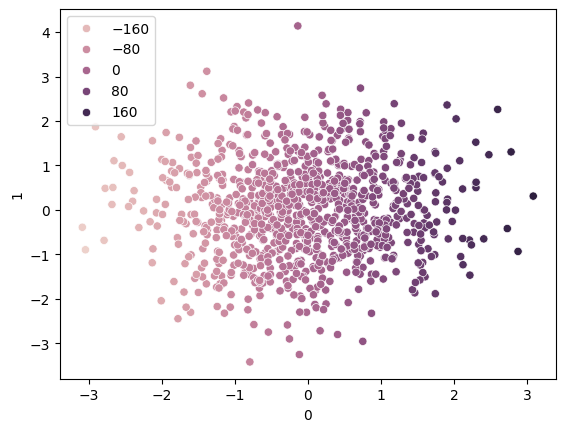

In [8]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [10]:
from sklearn.svm import SVR

In [11]:
svr=SVR(kernel='linear')

In [12]:
svr.fit(X_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [13]:
svr.coef_

array([[63.9164637 ,  2.51160045]])

In [14]:
## Prediction
y_pred=svr.predict(X_test)

In [15]:
y_pred

array([ 5.63705769e+01, -1.69698574e+01, -4.71218128e+01,  6.86238674e+00,
       -1.04342923e+01,  9.30859533e+01,  7.09036968e+00, -3.18775563e+01,
        2.27935567e+01, -7.96492992e+01, -6.86913273e+00, -4.24466532e+01,
        1.99364990e+01, -6.66894091e+01, -6.78129033e+01, -1.82493809e+01,
        4.01739667e+01, -2.83086115e+01,  5.71271179e+01, -5.85558085e+01,
       -1.06920216e+02,  5.73477526e+01,  4.20587854e+01, -4.15206721e+01,
        1.11085927e+01, -6.76092884e+01, -4.68979333e+01, -1.25248942e+02,
       -9.53433231e+00,  2.63997675e+01,  3.83540421e+01,  1.12704542e+02,
        6.89234004e+01, -6.25960903e+01, -1.57541628e+01,  1.06412216e+01,
        2.91640023e+01, -3.34237289e+01, -7.77361500e+01,  8.78104168e+01,
       -4.36317959e+01,  4.95253989e+00,  2.42579581e+01, -1.19715504e+02,
       -1.18877356e+01, -1.83457269e+01,  5.76736594e+00, -6.34460272e+01,
        8.45383534e+01,  9.70943361e+01, -1.10607469e+02,  5.18285096e+01,
       -3.88720146e+01,  

In [16]:
from sklearn.metrics import r2_score

In [17]:
print(r2_score(y_test,y_pred))

0.9978538404356102


## Hyperparametere Tuning With SVR

In [18]:
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel':['linear'],
              'epsilon':[0.1,0.2,0.3]
              }

In [19]:
grid=GridSearchCV(SVR(),param_grid=param_grid,refit=True,cv=5,verbose=3)

In [20]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.914 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.927 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.927 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.925 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.924 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.914 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.927 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.927 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.925 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.924 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'epsilon': [0.1, 0.2, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [21]:
grid.best_params_

{'C': 100, 'epsilon': 0.3, 'gamma': 1, 'kernel': 'linear'}

In [22]:
## Prediction
y_pred4=grid.predict(X_test)
print(r2_score(y_test,y_pred4))

0.9978569574563282
